In [1]:
#alternative method using artificial neural network (ANN) to price options looking 
#at the efficiency of the ANN to learn the Black-Scholes option pricing formulas

In [2]:
#An artificial neural network (ANN) is a computational system inspired by the biological neural 
#network found in animal brains. It consists of a collection of interconnected nodes, called neurons, 
#which are organised into layers.

#The neurons in each layer receive weighted inputs, process them through an activation function,
# and then pass the results to the neurons in the next layer. The neurons in the input layer receive 
#input signals from the external environment while the neurons in the output layer produce the output. 
#Hidden layers are intermediate layers between input and output layers.

#The connections between neurons are weighted, which means that some inputs have a stronger 
#influence on the output of the neuron than others. These weights are adjusted during training 
#to improve the performance of the network for a specific objective.

A First Simple Example: Estimation of a Parabolic Function
Let’s have a look at a first simple example with Python code. We will train a neural network to estimate a parabolic function. 
We will build the ANN with Keras framework in Python. 

In [4]:
import warnings
warnings.filterwarnings('ignore')

#import libraries
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import math
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import r2_score

In [5]:
#function we want to approximate 
#y = 3 * x^2 + 6
def f(x):
    return 3 * x**2 + 6
x = np.arange(-10, 10.01, .01)
y = f(x)

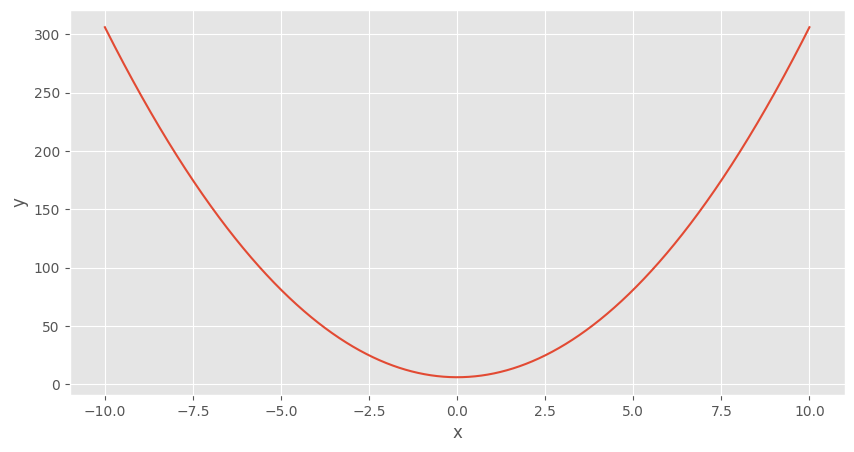

In [6]:
plt.figure(figsize = (10,5))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [7]:
#We use values between -10 and 10 for x in the dataset. 
#We split the dataset between the training and test dataset, with a split of 75% for the training and 25% for the test.

In [8]:
#build the training and test datasets
X = x
y = y
X_train, X_test, y_train, y_test = \
train_test_split(X, y, test_size=0.25, random_state=0)

In [9]:
#Then we build the ANN with four layers, with 10 neurons each.

ANN = Sequential()
ANN.add(Dense(10,input_dim = 1, activation = 'relu'))
ANN.add(Dense(10, activation = 'relu'))
ANN.add(Dense(10, activation = 'relu'))
ANN.add(Dense(10, activation = 'relu'))         
ANN.add(Dense(1))

In [10]:
#We use the mean squared error for the loss function and the Adam algorithm to minimize it, 
#fitting the model on the training dataset. We use a batch size equal to 16 and 150 epochs here.

#Loss function = MSE, optimizer: Adam
ANN.compile(loss = 'mean_squared_error', optimizer='adam')
# fit the ANN on the training dataset
ANN.fit(X_train, y_train, epochs = 150, batch_size = 16)

Epoch 1/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 19042.5020
Epoch 2/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18198.3379
Epoch 3/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8543.4043
Epoch 4/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1481.2955
Epoch 5/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1335.8359
Epoch 6/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1189.8292
Epoch 7/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1077.4626
Epoch 8/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 947.5761
Epoch 9/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 892.5808
Epoch 10/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 825.6499
Epoch 11/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 741.1644
Epoch 12/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 685.0668
Epoch 13/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 588.6586
Epoch 14/150
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 550.1940
Epoch 15/150
94/94 ━━━━━━━━━━━━━━━

In [11]:
#We estimate the values on the test dataset.

#prediction
y_pred = ANN.predict(X_test)



16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


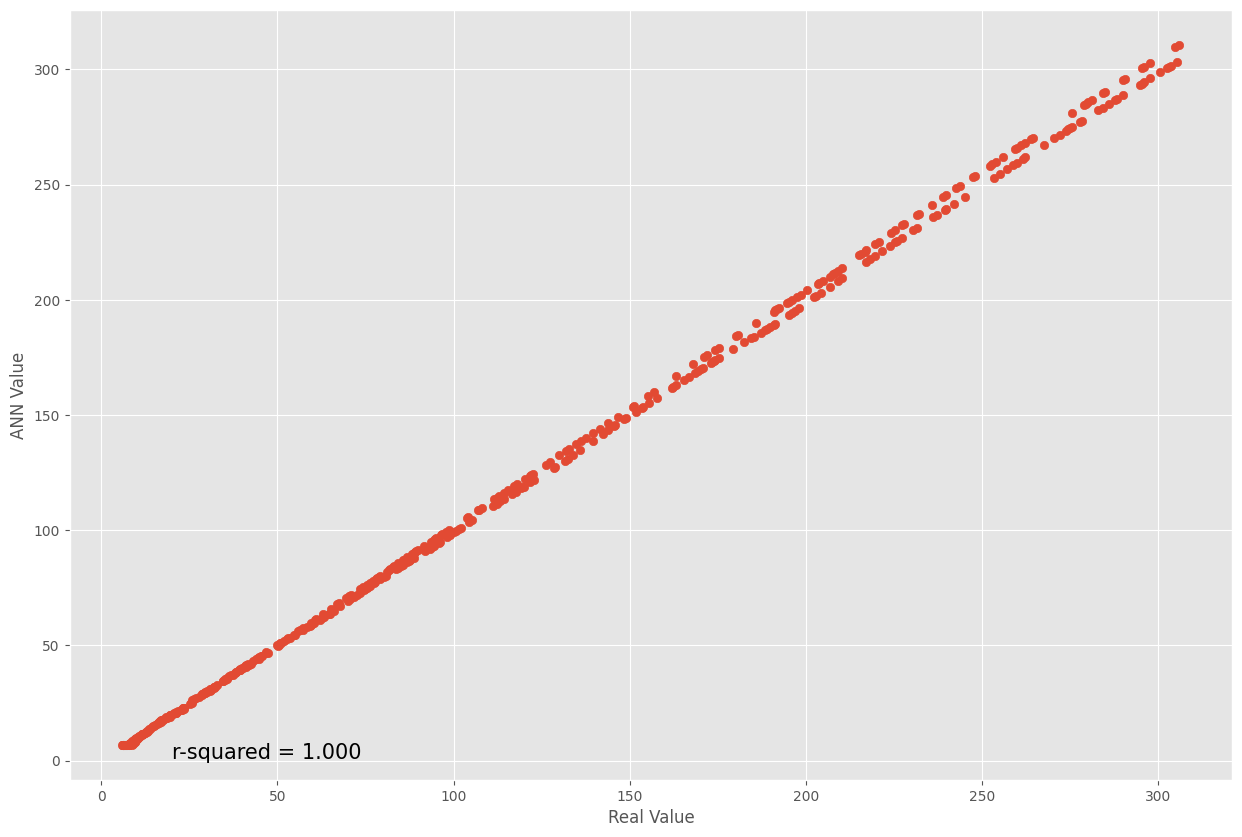

In [12]:
#And we compare the estimations from the model with the real values, with a strong relationship between the two.

#Comparison real values and predictions on test dataset
plt.figure(figsize = (15,10))
plt.scatter(y_test, y_pred)
plt.xlabel("Real Value")
plt.ylabel("ANN Value")
plt.annotate("r-squared = {:.3f}".format(r2_score(y_test, y_pred)), (20, 1), size = 15)
plt.show();

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


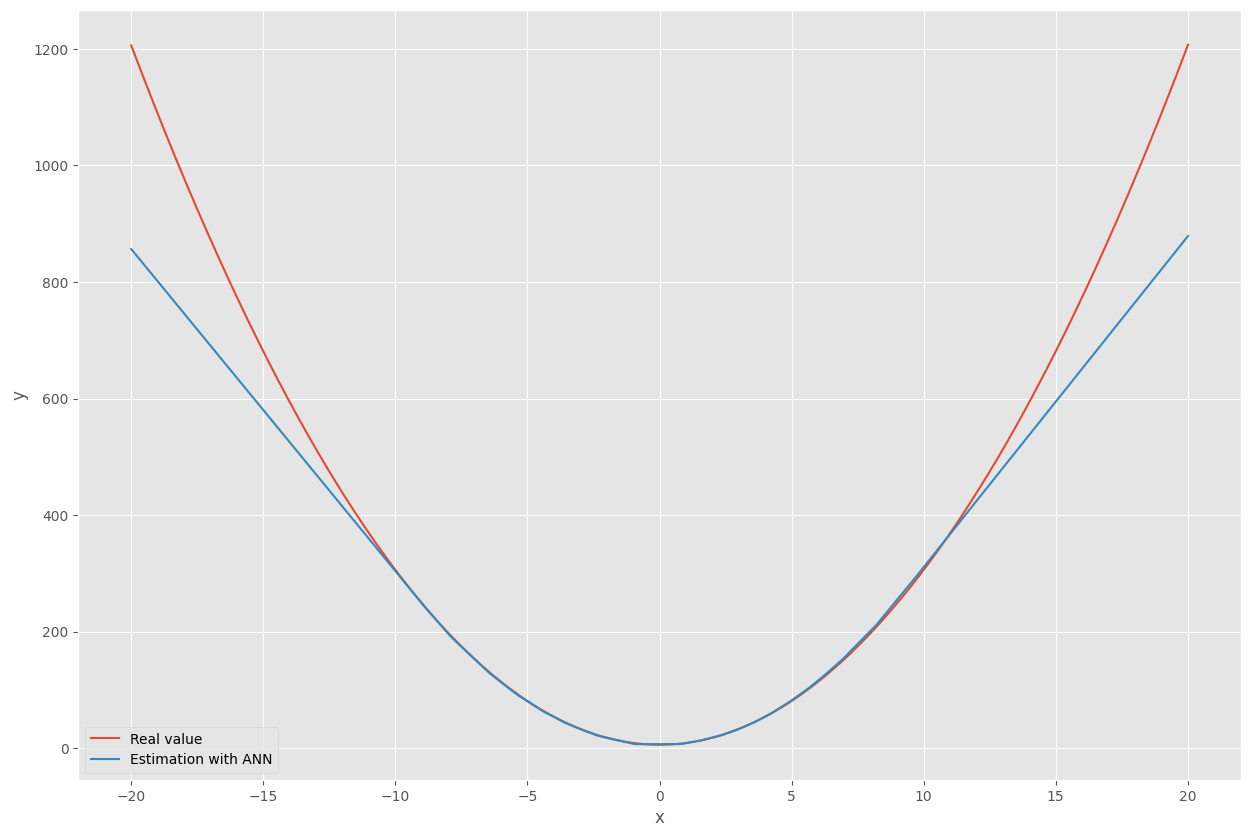

In [13]:
#However, the efficiency of the model is more limited for extrapolating the curve.

#Extrapolation with ANN
X = np.arange(-20, 20.01, .01)
y = f(X)
y_pred = ANN.predict(X)

plt.figure(figsize = (15,10))
plt.plot(X, y, label = "Real value")
plt.plot(X, y_pred, label = "Estimation with ANN")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


Black-Scholes Formula with ANN

In [14]:
class EuropeanOptionBS:

    def __init__(self, S, K, T, r, q, sigma,Type):
        self.S = S
        self.K = K
        self.T = T
        self.r = r
        self.q = q        
        self.sigma = sigma
        self.Type = Type
        self.d1 = self.d1()
        self.d2 = self.d2()
        self.price = self.price()
        
    def d1(self):
        d1 = (math.log(self.S / self.K) \
                   + (self.r - self.q + .5 * (self.sigma ** 2)) * self.T) \
                    / (self.sigma * self.T ** .5)       
        return d1

    def d2(self):
        d2 = self.d1 - self.sigma * self.T ** .5     
        return d2
    
    def price(self):
        if self.Type == "Call":
            price = self.S * math.exp(-self.q * self.T) * norm.cdf(self.d1) \
            - self.K * math.exp(-self.r *self.T) * norm.cdf(self.d2)
        if self.Type == "Put":
            price = self.K * math.exp(-self.r * self.T) * norm.cdf(-self.d2) \
            - self.S * math.exp(-self.q * self.T) * norm.cdf(-self.d1)            
        return price

In [15]:
#dataset
r = np.arange(.0, .1, .01) #interest rates
Strike = np.arange(50, 155, 5) #strike price
T = np.arange(0.1, 2.1, 0.1) #time to maturity
sigma = np.arange(0.1, 2.1, .1) #volatility

data = []
for r_ in r:
    for Strike_ in Strike:
        for T_ in T:
            for sigma_ in sigma:
                data.append([r_, Strike_, T_, sigma_, \
                             EuropeanOptionBS(100, Strike_, T_, r_, 0, sigma_, "Call").price])
data = np.asarray(data)

In [16]:
#training and test datasets
X = data[:,:4] #params r, strike, T, sigma
y = data[:,4:5] #call price
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [17]:
#ANN with four layers, 10 neurons each
#activation function: ReLU
ANN = Sequential()
ANN.add(Dense(10,input_dim = 4, activation = 'relu'))
ANN.add(Dense(10, activation = 'relu'))
ANN.add(Dense(10, activation = 'relu'))
ANN.add(Dense(10, activation = 'relu'))         
ANN.add(Dense(1))

In [ ]:
#Loss function = MSE, optimizer: Adam
ANN.compile(loss = 'mean_squared_error', optimizer='adam')
# fit the ANN on the training dataset
ANN.fit(X_train, y_train, epochs = 150, batch_size = 16)

In [ ]:
#prediction
y_pred = ANN.predict(X_test)

#Comparison real values and predictions on test dataset
plt.figure(figsize = (15,10))
plt.scatter(y_test, y_pred)
plt.xlabel("Real Value")
plt.ylabel("ANN Value")
plt.annotate("r-squared = {:.3f}".format(r2_score(y_test, y_pred)), (20, 1), size = 15)
plt.show();

In [ ]:
#Now, we compare the price of an option with a strike price at 120, a time to maturity at 6 months (0.5), 
#the risk-free interest rate at 5% and the implied volatility at 30% when changing the asset price.

K = 120 #strike price
r = 0.05 #risk-free interest rate
sigma = .3 #implied volatiltiy
T = .5 #time to maturity
S = np.arange(50, 151, 1) #asset prices

PriceBS = [EuropeanOptionBS(S_, K, T, r, 0, sigma, "Call").price for S_ in S]
PriceANN = [S_ / 100 * \
            ANN.predict(np.array([[r, K / S_ * 100, T, sigma]]))[0][0] for S_ in S]

In [ ]:
#Even if we obtain good approximations for the prices, the estimation of the greeks 
#may be more unstable which can be an issue of course. 

#Comparison BS vs ANN prices
plt.figure(figsize = (15,10))
plt.plot(S, PriceBS, label = "Black-Scholes price")
plt.plot(S, PriceANN, label = "ANN price")
plt.xlabel("Asset Price")
plt.ylabel("Call Price")
plt.show();